In [ ]:
import numpy as np
import re
import nltk
from nltk import download
from nltk.corpus import twitter_samples
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer ,SnowballStemmer
from nltk.tag import pos_tag
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report


download(['twitter_samples'])
download('wordnet')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# prepare set of positive and negative tweets
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

In [ ]:
print(len(all_positive_tweets))
print(len(all_negative_tweets))

5000
5000


In [ ]:
# so classes are balanced

In [ ]:
# putting all tweets together
all_tweets = all_positive_tweets + all_negative_tweets

In [ ]:
# creating y (labels)

# assigning 1 to positive tweets
# assigning 0 to nagative tweets
y = [ 1 for _ in range(len(all_positive_tweets)) ] + [ 0 for _ in range(len(all_negative_tweets)) ]


In [ ]:
#################################################################################################################################################################################

In [ ]:
# step1 : preprocessing the tweets

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=4fb9d808732a8fb57f8bf896a0417026c7df0c482b77bab6b4cfff69b3b5b487
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 12.5 MB/s eta 0:00:00


In [ ]:
# expand contractions (don't -> do not)

import contractions

def expand_contractions(text):
    expanded_text = contractions.fix(text)
    return expanded_text


In [ ]:

slang_dict = {
    "lol": "laugh out loud",
    "brb": "be right back",
    "gtg": "got to go",
    "ttyl": "talk to you later",
    "omg": "oh my god",
    "idk": "i don’t know",
    "bff": "best friends forever",
    "fyi": "for your information",
    "tmi": "too much information",
    "smh": "shaking my head",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "lmao": "laughing my ass off",
    "yolo": "you only live once",
    "fomo": "fear of missing out",
    "dm": "direct message",
    "nsfw": "not safe for work",
    "tldr": "too long; didn’t read",
    "bae": "before anyone else",
    "wtf": "what the f***",
    "ppl": "people",
    "bffl": "best friends for life",
    "jk": "just kidding",
    "tbt": "throwback thursday",
    "rofl": "rolling on the floor laughing",
    "wbu": "what about you?",
    "hbu": "how about you?",
    "imo": "in my opinion",
    "icymi": "in case you missed it",
    "bffae": "best friends forever and ever",
    "dms": "direct messages",
    "sfw": "safe for work",
    "fomo": "fear of missing out",
    "yoyo": "you're on your own",
    "l8r": "later",
    "cya": "see you",
    "xoxo": "hugs and kisses",
    "wyd": "what you doing?",
    "nbd": "no big deal",
    "btt": "back to topic",
    "b4": "before",
    "tldr": "too long; didn't read",
    "fml": "f*** my life",
    "iirc": "if i recall correctly",
    "dm": "direct message",
    "smdh": "shaking my damn head",
    "bruh": "bro (used to express disbelief)",
    "sus": "suspicious",
    "vibes": "good feelings or atmosphere",
    "bae": "before anyone else",
    "h8": "hate",
    "tbf": "to be fair",
    "qotd": "quote of the day",
    "ootd": "outfit of the day",
    "rip": "rest in peace",
    "bop": "a good song",
    "fomo": "fear of missing out",
    "simp": "someone who shows excessive sympathy",
    "lit": "exciting or excellent",
    "goat": "greatest of all time",
    "binge": "to consume excessively",
    "clt": "can't live without",
    "dnd": "do not disturb",
    "litaf": "lit as f***",
    "nvm": "never mind",
    "so": "shout out",
    "bff": "best friend forever",
    "tmi": "too much information",
    "lqtm": "laughing quietly to myself",
    "fyp": "for you page (tiktok)",
    "wya": "where you at?",
    "slay": "to succeed or look great",
    "hml": "hit me up",
    "wis": "what i said",
    "pov": "point of view",
    "rip": "rest in peace",
    "ngl": "not gonna lie",
    "ymmv": "your mileage may vary",
    "cba": "can’t be arsed",
    "hth": "hope this helps",
    "tldr": "too long; didn't read",
    "pita": "pain in the a**",
    "vaf": "very annoying friend",
    "wth": "what the heck",
    "kms": "kill myself (used humorously)",
    "mfw": "my face when",
    "fubar": "f***ed up beyond all recognition",
    "snafu": "situation normal: all f***ed up",
    "tba": "to be announced",
    "eta": "estimated time of arrival",
    "hbd": "happy birthday",
    "lqtm": "laughing quietly to myself",
    "rsvp": "répondez s'il vous plaît (please respond)",
    "grwm": "get ready with me",
    "sis": "sister (used as a term of endearment)",
    "fam": "family or close friends",
    "g2g": "got to go",
    "wbu": "what about you?",
    "fomo": "fear of missing out",
    "goat": "greatest of all time",
    "cya": "see you",
    "fomo": "fear of missing out",
    "hbu": "how about you?",
    "tldr": "too long; didn't read",
    "simp": "someone who shows excessive sympathy",
    "lfg": "looking for group (gaming)",
    "nbd": "no big deal",
    "bff": "best friends forever",
    "ppl": "people",
    "lfg": "looking for group",
    "sis": "sister (used informally)",
    "rip": "rest in peace",
    "fomo": "fear of missing out",
    "wya": "where you at?",
    "btw": "by the way",
    "ftw": "for the win",
    "tldr": "too long; didn't read",
    "bda": "big deal alert",
    "srs": "serious",
    "fomo": "fear of missing out",
    "mia": "missing in action",
    "bff": "best friends forever",
    "bffl": "best friends for life",
    "cya": "see you",
    "dm": "direct message",
    "mfw": "my face when",
    "tmi": "too much information",
    "sop": "standard operating procedure",
    "nbd": "no big deal",
    "p2p": "peer to peer",
    "fomo": "fear of missing out",
    "yolo": "you only live once",
    "tldr": "too long; didn't read",
    "accnt" : "account",
    "rqst" : "request",
    "fb" : "facebook",
    "lwwf" : "love wins we fight",
    ":)": "smile",
    ":(": "frown",
    ":D": "laughing",
    ":P": "playful or teasing",
    ":O": "surprised",
    ":|": "neutral",
    ":S": "confused",
    ";)": "wink",
    ":/": "unsure or skeptical",
    ":*": "kiss",
    "B)": "cool",
    ":'(": "crying",
    "XD": "laughing hard",
    "^-^": "happy",
    "^_^": "smiling",
    "o_O": "bewildered",
    ">_<": "frustrated",
    "<3": "heart",
    "</3": "broken heart",
    ">:(": "angry",
    "T_T": "crying",
    ":-)": "smile",
    ":-(": "frown",
    ":-D": "laughing",
    ":-P": "playful or teasing",
    ":-O": "surprised",
    ":-|": "neutral",
    ":-S": "confused",
    ";-)": "wink",
    ":-/": "unsure or skeptical",
    ":-*": "kiss",
    "B-)": "cool",
    ":'-(": "crying",
    "X-D": "laughing hard",
    "^-^": "happy",
    "^_^": "smiling",
    "o_O": "bewildered",
    ">_<": "frustrated",
    "<3": "heart",
    "</3": "broken heart",
    ">:(" : "angry",
    "T_T": "crying",
    "O_O": "surprised",
    "0_o": "confused",
    ":-X": "sealed lips",
    ":3": "cute",
    ":v": "peace",
    ":-]": "happy",
    ":-[": "sad",
    ":?": "questioning",
    ":-c": "disappointed",
    ":-b": "playful",
    "D:": "shocked",
    "D8": "disgusted",
    "X_x": "dead or tired",
    ":-@": "screaming",
    "O.O": "shocked",
    ":-)": "happy",
    ":-(": "sad",
    ":-/": "confused",
    ":-|": "meh",
    ":-*": "kiss",
    ":^)": "smirking",
    ":<": "sad",
    ":-]": "happy",
    ":-<": "sad",
    ":}": "smirk",
    ":)": "smile",
    ":(": "frown",
    ":D": "grin",
    ":P": "teasing",
    ";)": "wink",
    ":|": "neutral",
    ":o": "surprise",
    ":S": "confusion",
    ":X": "sealed lips",
    "ttyl" : "talk to you later",
}

In [ ]:
def replace_abbreviations(tweet, slang_dictionary):
    for emoticon, meaning in slang_dictionary.items():
        tweet = tweet.replace(emoticon, meaning)
    return tweet

# Example usage
emoticon_dict = {':)': 'smile', ':(': 'sad', ':D': 'grin'}
text = 'I love this :) but sometimes I feel :('
result = replace_abbreviations(text, emoticon_dict)
print(result)


I love this smile but sometimes I feel sad


In [ ]:
# The Punkt tokenizer is a pre-trained unsupervised machine learning model used for sentence splitting and word tokenization.
download('punkt_tab')
# The Averaged Perceptron Tagger is a pre-trained model used for part-of-speech (POS) tagging.
download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
# Example for testing replace_abbreviations function
tweet = "lol, I'm so excited for the party! ttyl!"
#tweet = word_tokenize(tweet)

# Replace abbreviations in the tweet
result = replace_abbreviations(tweet, slang_dict)
print(result)

laugh out loud, I'm shout out excited for the party! talk to you later!


In [ ]:
# downloading stop words (the words that carry little meaningful information for specific tasks)
download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# customizing stop words
default_stopwords = set(stopwords.words('english'))
customized_stopwords = default_stopwords - set(['no', 'not', 'ain','aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't",'weren',"weren't",'won',"won't",'wouldn',"wouldn't"])


In [ ]:
# this is a general function containing all steps of preprocessing

def preprocessor(all_tweets):

    processed_tweets = []

    for tweet in all_tweets:

        # Convert to lowercase
        tweet = tweet.lower()
        # print('lower: ')
        # print(tweet)
        # print('------------------------------------------------')

        # Remove links, tags, and hashtags using regular expressions
        tweet = re.sub(r"http\S+|www\S+|https\S+|@\w+|#\w+", "", tweet)
        # print('remove tags:')
        # print(tweet)
        # print('------------------------------------------------')

        # language detecting
        # it was working wrong
        # language = detect(tweet)
        # if language != 'en' :
        #   print(language)
        #   print('------------------------------------------------')

        # expanding contractions
        tweet = expand_contractions(tweet)
        # print('expanded : ')
        # print(tweet)
        # print('------------------------------------------------')

        # expanding online abbreviations
        tweet = replace_abbreviations(tweet , slang_dict)
        # print('abbr: ')
        # print(tweet)
        # print('------------------------------------------------')

        # tokenize into words
        tweet = word_tokenize(tweet)
        # print('tokenize')
        # print(tweet)
        # print('------------------------------------------------')

        # Remove special characters and punctuations
        for ind , token in enumerate(tweet) :
          token = re.sub(r'[^a-zA-Z\s]', '', token)
          tweet[ind] = token
        # print('remove punc: ')
        # print(tweet)
        # print('------------------------------------------------')

        # deleting stop words and empty strings
        filtered_tokens = [token for token in tweet if token not in customized_stopwords and token != '']
        # print('removing stop words and empty strings: ')
        # print(filtered_tokens)
        # print('------------------------------------------------')

        # pos tagging
        tagged_tokens = nltk.pos_tag(filtered_tokens)
        # print('pos tagging: ')
        # print(tagged_tokens)
        # print('------------------------------------------------')

        # finding roots of words
        snowball = SnowballStemmer("english")
        #stemmer = PorterStemmer()
        lemmatizer = WordNetLemmatizer()

        root_tokens = []
        for token in tagged_tokens:
            if token[1] == 'JJ':
                #root = stemmer.stem(token[0])
                root = snowball.stem(token[0])
            else:
                root = lemmatizer.lemmatize(token[0])

            root_tokens.append(root)

        # print('root tokens:')
        # print(root_tokens)
        # print('------------------------------------------------')
        # joining tokens together
        joined_tweet = ' '.join(root_tokens)
        # print('joined tokens: ')
        # print(joined_tweet)
        # print('------------------------------------------------')
        processed_tweets.append(joined_tweet)

    return processed_tweets


In [ ]:
# processed_tweets = preprocessor(all_tweets[30:40])
# print(processed_tweets)

In [ ]:
processed_tweets = preprocessor(all_tweets)

In [ ]:
type(processed_tweets)

list

In [ ]:
# here we have preprocessed and cleaned tweets as strings

In [ ]:
################################################################################################################################################################################

In [ ]:
# storing cleaned data in a csv file
import csv

# Write data to CSV file
with open('cleaned_data.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    for tweet in processed_tweets:
        writer.writerow([tweet])

print("Data saved to cleaned_data.csv")


Data saved to cleaned_data.csv


In [ ]:
################################################################################################################################################################################

In [ ]:
# Step2: convert the text data to numerical type (TF_IDF)
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(processed_tweets)

In [ ]:
print(X[0])
print(X.shape)
print(type(X))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (1, 10136)>
  Coords	Values
  (0, 9080)	0.4277302936731433
  (0, 2708)	0.5291269828507519
  (0, 5531)	0.4604040648841983
  (0, 1737)	0.43691102222150263
  (0, 9697)	0.3414887345390823
  (0, 8233)	0.13264136525198872
(10000, 10136)
<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
# storing tf-idf result in a csv file

# Write data to CSV file
with open('tf_idf_data.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    for num in X:
        writer.writerow([num])

print("Data saved to tf_idf_data.csv")

Data saved to tf_idf_data.csv


In [ ]:
#############################################################################################################################################################################

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


In [ ]:
# creating the models

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score

# Define the parameter grids for each model
param_grid_lr = {
    'C': [0.1, 1, 10],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'solver': ['liblinear']  # Solver for optimization
}

param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0],  # Smoothing parameter
    'fit_prior': [True, False]  # Whether to learn class prior probabilities
}

param_grid_svm = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'kernel': ['linear', 'rbf'],  # Kernel type
    'gamma': ['scale', 'auto']  # Kernel coefficient for 'rbf'
}

# Initialize the models
log_reg = LogisticRegression()
naive_bayes = MultinomialNB()
svm = SVC()

# Perform Grid Search for Logistic Regression
grid_search_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='f1', verbose=1)
grid_search_lr.fit(X_train, y_train)

# Perform Grid Search for Naive Bayes
grid_search_nb = GridSearchCV(naive_bayes, param_grid_nb, cv=5, scoring='f1', verbose=1)
grid_search_nb.fit(X_train, y_train)

# Perform Grid Search for SVM
grid_search_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='f1', verbose=1)
grid_search_svm.fit(X_train, y_train)

# Get the best models
best_lr = grid_search_lr.best_estimator_
best_nb = grid_search_nb.best_estimator_
best_svm = grid_search_svm.best_estimator_

# Evaluate the best models on the test set
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

print("Logistic Regression Results:")
evaluate_model(best_lr, X_test, y_test)

print("Naive Bayes Results:")
evaluate_model(best_nb, X_test, y_test)

print("SVM Results:")
evaluate_model(best_svm, X_test, y_test)

# Print the best hyperparameters
print("Best Logistic Regression Parameters:", grid_search_lr.best_params_)
print("Best Naive Bayes Parameters:", grid_search_nb.best_params_)
print("Best SVM Parameters:", grid_search_svm.best_params_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       508
           1       0.99      1.00      0.99       492

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

F1 Score: 0.9939
Naive Bayes Results:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       508
           1       0.97      0.89      0.93       492

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000

F1 Score: 0.9258
SVM Results:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       508
           1       

In [ ]:
##############################################################################################################################################################################

In [ ]:
# Using vader model

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.7 MB/s eta 0:00:00


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER
vader = SentimentIntensityAnalyzer()

# Update lexicon with custom sentiment scores
vader.lexicon.update({
    'smile': 1.0,
    'frown': -1.0,
    'please': 0.5,
    'hope': 0.5,
    'love': 2.5,
})

# Define thresholds for evaluation
# we want to generate [0.05, 0.1, ..., 0.95]
thresholds = [round(i * 0.05, 2) for i in range(1, 20)]

# Store best threshold and its corresponding F1-score
best_threshold = None
best_f1 = 0
best_report = ""

# Evaluate VADER sentiment analysis across thresholds
for threshold in thresholds:
    y_pred = []

    # Predict sentiment for each tweet
    for tweet in processed_tweets:
        sentiment_scores = vader.polarity_scores(tweet)
        compound_score = sentiment_scores['compound']

        # Classify based on threshold
        y_pred.append(1 if compound_score >= threshold else 0)

    # Calculate F1-score and classification report
    current_f1 = f1_score(y, y_pred)
    report = classification_report(y, y_pred)

    # Update best threshold if current F1-score is higher
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold
        best_report = report

# Print the best threshold and its classification report
print(f"Best Threshold: {best_threshold}")
print(f"Best F1-Score: {best_f1}")
print("Classification Report:")
print(best_report)


Best Threshold: 0.25
Best F1-Score: 0.8015676567656765
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81      5000
           1       0.83      0.78      0.80      5000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



In [ ]:
# printing the tweets that it is predicting wrong

# for ind , result in enumerate(y_pred):
#   if result != y[ind]:
#     print(all_tweets[ind])
#     print(processed_tweets[ind])
#     print('y_pred : ' , result)
#     print('y : ' , y[ind])
#     for token in processed_tweets[ind].split():
#         if token.lower() in vader.lexicon:
#             score = vader.lexicon[token.lower()]
#             print(f"Token: {token}, Score: {score}")
#         else:
#             print(f"Token: {token}, Score: Not in lexicon")
#     print('----------------------------------------------------------------')

In [ ]:
###############################################################################################################################################################################

In [ ]:
# Using bert and distilbert

In [ ]:
!pip install transformers

In [ ]:
!pip install datasets==2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.5/325.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.9 MB/s eta 0:00:00


In [ ]:
# set the gpu

In [ ]:
X_train.shape

(9000, 10136)

In [ ]:
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.metrics import accuracy_score

# disabling the connection to WANDB site
import os
os.environ["WANDB_DISABLED"] = "true"

# Ensure X_train and y_train are dense lists or arrays
# X_train = X_train.toarray()
# X_test = X_test.toarray()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(processed_tweets, y, test_size=0.1, random_state=42)

# 1. Create Hugging Face Datasets from your data
train_dataset = Dataset.from_dict({'text': X_train, 'label': y_train})
test_dataset = Dataset.from_dict({'text': X_test, 'label': y_test})

# 2. Load pre-trained BERT model and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 3. Preprocess the data
def preprocess_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True)

encoded_train_dataset = train_dataset.map(preprocess_function, batched=True)
encoded_test_dataset = test_dataset.map(preprocess_function, batched=True)

# 4. Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    # ... other training arguments ...
)

# 5. Define Trainer and fine-tune
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_train_dataset,
    eval_dataset=encoded_test_dataset,
)

trainer.train()

# 6. Predict on X_test using the fine-tuned model
predictions = trainer.predict(encoded_test_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=1)

# 7. Evaluate performance
accuracy = accuracy_score(y_test, predicted_labels)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, predicted_labels))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/9 [00:00<?, ?ba/s]

  0%|          | 0/1 [00:00<?, ?ba/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
500,0.062000
1000,0.030400


Accuracy: 0.9950
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       508
           1       0.99      1.00      0.99       492

    accuracy                           0.99      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      0.99      1.00      1000



In [ ]:
##############################################################################################################################################################################

In [ ]:
# storing data for future usage

# Write data to CSV file
with open('y_pred_bert.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    for label in predicted_labels:
        writer.writerow([label])

print("Data saved to y_pred_bert.csv")

Data saved to y_pred_bert.csv


In [ ]:
######################################################################################################################################3

In [ ]:
# data visualization

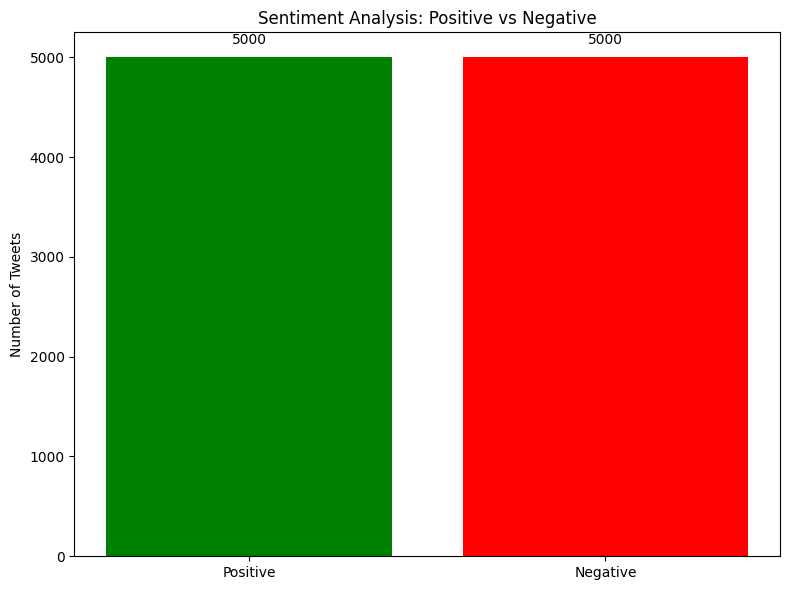

In [ ]:
# balance of data
import matplotlib.pyplot as plt

# Example data: Counts of positive and negative tweets
sentiment_counts = {'Positive': 5000, 'Negative': 5000}

# Create a bar chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(sentiment_counts.keys(), sentiment_counts.values(), color=['green', 'red'])

# Add labels and title
ax.set_ylabel('Number of Tweets')
ax.set_title('Sentiment Analysis: Positive vs Negative')

# Add value labels to the bars
for i, value in enumerate(sentiment_counts.values()):
    ax.text(i, value + 100, str(value), ha='center', va='bottom')

# Show the plot
plt.tight_layout()
plt.show()



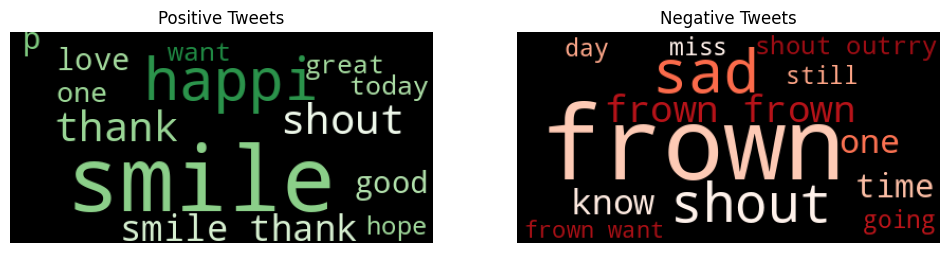

{'smile': 1.0, 'happi': 0.2857744107744108, 'shout': 0.12373737373737374, 'thank': 0.12247474747474747, 'smile thank': 0.08964646464646464, 'love': 0.06439393939393939, 'good': 0.06355218855218855, 'p': 0.06186868686868687, 'one': 0.055134680134680134, 'want': 0.0484006734006734, 'great': 0.047979797979797977, 'today': 0.047979797979797977, 'hope': 0.04377104377104377}
{'frown': 1.0, 'sad': 0.16010978956999086, 'shout': 0.13327233912778286, 'frown frown': 0.05611466910643489, 'know': 0.04818542238487344, 'one': 0.04574565416285453, 'time': 0.043610856968587984, 'shout outrry': 0.04330588594083562, 'going': 0.039341262580054895, 'day': 0.03873132052455017, 'miss': 0.03812137846904544, 'still': 0.037816407441293075, 'frown want': 0.034156755108264714}


In [ ]:
# words more repeated in positive and negative tweets
from wordcloud import WordCloud

# separate positive and negative tweets
list_positives = [tweet for ind , tweet in enumerate(processed_tweets) if y[ind] == 1]
list_negatives = [tweet for ind , tweet in enumerate(processed_tweets) if y[ind] == 0]

# put all positive tweets in one string , for negatives as well
string_positive_tweets = " ".join(list_positives)
string_negative_tweets = " ".join(list_negatives)

# Generate word clouds
positive_wc = WordCloud(background_color='black', colormap='Greens', max_words=13).generate(string_positive_tweets)
negative_wc = WordCloud(background_color='black', colormap='Reds', max_words=13).generate(string_negative_tweets)


# Plot word clouds
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(positive_wc)
axes[0].set_title('Positive Tweets')
axes[0].axis('off')

axes[1].imshow(negative_wc)
axes[1].set_title('Negative Tweets')
axes[1].axis('off')

plt.show()
print(positive_wc.words_)
print(negative_wc.words_)

In [ ]:
# saving pictures as png

plt.savefig('sentiment_analysis.png', dpi=300, bbox_inches='tight')
positive_wc.to_file("positive_wc.png")
negative_wc.to_file("negative_wc.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
############################################################################# TRASH CAN #####################################################################################

In [ ]:
# we can translate emojis too , later.
import re

def remove_emojis(text):
    # Define a regex pattern for matching emojis
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # Left Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbols & Pictographs
        u"\U0001F680-\U0001F6FF"  # Transport & Map Symbols
        u"\U0001F1E0-\U0001F1FF"  # Flags (iOS)
        u"\U00002700-\U000027BF"  # Dingbats
        u"\U00002600-\U000026FF"  # Miscellaneous Symbols
        u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
        u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
        u"\U00002500-\U00002BEF"  # Chinese characters
        u"\u200d"                 # Zero-width joiner
        u"\u2640-\u2642"          # Gender symbols
        u"\u2600-\u2B55"          # Miscellaneous symbols and arrows
        u"\u23cf"                 # Eject symbol
        u"\u23e9"                 # Fast forward
        u"\u231a"                 # Watch
        u"\ufe0f"                 # Dingbats
        u"\u3030"                 # Wavy dash
        "]+",
        flags=re.UNICODE,
    )
    return emoji_pattern.sub(r'', text)

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize the model
sia = SentimentIntensityAnalyzer()
sia.lexicon.update({
    ":(((": -2.5,  # Strong negative sentiment
    "frown": -2.0, # Strong negative sentiment
    "smile": 1.5,  # Positive sentiment (keep context in mind)
    "shout": 0.5,  # Neutral or slightly positive
    "poor": -2.1,  # Strong negative sentiment
    "joke": -0.5,  # Adjusted to reflect sarcasm better
    "privilege": 0, # Neutral sentiment
    "falsettos": 0, # Neutral sentiment
    "aww": -1.0,  # Mildly negative sentiment (sympathy)
    "poor": -2.1,  # Strong negative sentiment (already correct)
    "thing": 0,    # Neutral sentiment
    "frown": -2.0, # Strong negative sentiment
    "hope": 1.9,   # Positive sentiment (already correct)
    "it'okay": 1.5, # Positive sentiment (optimistic tone)
    "good": 2.0,   # Positive sentiment (slightly increased intensity)
    "health": 1.7, # Positive sentiment
    "luckely": 1.5, # Positive sentiment (optimism)
    "freed": 2.0,  # Strong positive sentiment
    "rocks": 0,    # Neutral sentiment

    "honestly": 2.0, # Positive sentiment (already correct)
    "love": 3.2,     # Strong positive sentiment (already correct)
    "shout": 0.5,    # Neutral or slightly positive
    "upset": -1.6,   # Negative sentiment (already correct)


    "upgrade??:-)": 1.5, # Positive sentiment


    "please": 1.3,   # Positive politeness (already correct)


    "tsunami": -2.5, # Strong negative sentiment
    "afraid": -2.0,  # Strong negative sentiment
    ":(((": -2.5,    # Strong negative emoji


    "no unfollowers": -1.2, # Negative due to absence of growth

    "kidding": 0.4,  # Slightly positive (playful tone)
    ":p": 1.0,       # Mildly positive emoji

    "interest": 2.0,   # Positive interest (already correct)
    "join": 1.2,       # Mildly positive action


    "feel": -0.5,      # Slightly negative in context of rejection
    "no": -1.2,         # Negative sentiment (absence or denial)
    "smile": 1.5,       # Positive sentiment (already correct)
    ":-(((": -2.5,      # Strong negative emoji
    "seriously": -0.7,  # Mildly negative sentiment (context-sensitive)
    "help": 1.7,        # Positive sentiment (assistance)
    "frown": -2.0,      # Strong negative sentiment (already correct)
    "happy": 2.7,       # Strong positive sentiment (already correct)
    "worth": 0.9,       # Mildly positive sentiment
    "loose": -1.3,      # Negative sentiment (loss or lack of control)
    "relaxes": 1.5,     # Positive sentiment (calming effect)
     ":d": 2.3,         # Strong positive sentiment (happy emoji)
    "bored": -1.1,     # Negative sentiment (lack of interest)
    "miss": -1.0,      # More negative than default (-0.6)
    "sexy": 2.4,       # Strong positive sentiment
    ":((((((((((": -3.0,  # Extremely negative emoji
    ":))))": 2.5,      # Strong positive emoji
    "frown": -2.0,     # Strong negative sentiment (already correct)
    "drop": -1.1,      # Negative sentiment (context-sensitive)
    "no": -1.2,        # Negative sentiment (absence or denial)
    "laugh": 2.6,      # Positive sentiment (joy or amusement)
    "not good": -2.0,  # Strong negative sentiment
    "sore": -1.8,      # Negative sentiment (painful context)
    "better": 1.9,     # Positive sentiment (improvement)
    "fun": 2.3,        # Strong positive sentiment
    ":(((": -2.5,      # Strong negative emoji
    "sunshine": 2.2,   # Positive sentiment (uplifting context)
})
# this model is created rule based , so we don't need to train it
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(processed_tweets, y, test_size=0.2, random_state=42, stratify=y)
print(X_test[0:10])
print(y_test[0:10])

y_pred = []
for tweet in X_test:
    # unlike other models it gets strings as input , not numerical values
    sentiment_scores = sia.polarity_scores(tweet)

    if sentiment_scores['compound'] >= 0.36:
        y_pred.append(1)  # Predict positive
    else:
        y_pred.append(0)  # Predict negative

# Evaluate performance
print('evaluation of VADER :')
print(classification_report(y_test, y_pred))